# Mandelbrot — Raw data exploration (no cleaning)

Quick look at the raw `results_linux.csv` for `mandelbrot`, focused on Haskell's surprising dominance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv(Path('../results/results_linux.csv'))
mb = df[df['benchmark'] == 'mandelbrot'].copy()

mb['cpu_energy_J'] = mb['cpu_energy_rapl_msr_component-package_0-uj'] / 1e6
mb['time_s']       = mb['phase_time_syscall_system-system-us'] / 1e6
mb['mem_energy_J'] = mb['memory_energy_rapl_msr_component-dram_0-uj'] / 1e6

print(f'Total rows: {len(mb)}  |  Languages: {mb["language"].nunique()}')

Total rows: 180  |  Languages: 18


## All 10 raw runs per language — strip plot

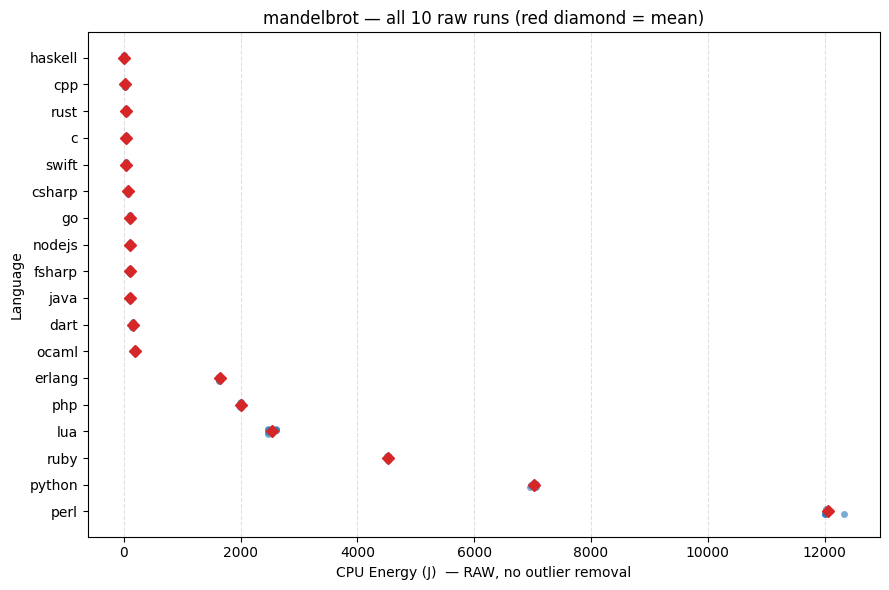

In [2]:
order = mb.groupby('language')['cpu_energy_J'].mean().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(9, 6))
sns.stripplot(data=mb, x='cpu_energy_J', y='language', order=order,
              jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax)

means = mb.groupby('language')['cpu_energy_J'].mean()
for i, lang in enumerate(order):
    ax.plot(means[lang], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.set_xlabel('CPU Energy (J)  — RAW, no outlier removal')
ax.set_ylabel('Language')
ax.set_title('mandelbrot — all 10 raw runs (red diamond = mean)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Haskell run-by-run detail

In [3]:
haskell = mb[mb['language'] == 'haskell'][['measured_at', 'cpu_energy_J', 'time_s', 'mem_energy_J']].copy()
haskell = haskell.sort_values('measured_at').reset_index(drop=True)
haskell.index.name = 'run'

print(f'Mean  : {haskell["cpu_energy_J"].mean():.4f} J')
print(f'Std   : {haskell["cpu_energy_J"].std():.4f} J')
print(f'Min   : {haskell["cpu_energy_J"].min():.4f} J')
print(f'Max   : {haskell["cpu_energy_J"].max():.4f} J')
print()
haskell

Mean  : 0.8462 J
Std   : 0.0505 J
Min   : 0.7776 J
Max   : 0.9401 J



,measured_at,cpu_energy_J,time_s,mem_energy_J
run,,,,
0,2026-05-10 17:21:01,0.777648,0.176947,0.097167
1,2026-05-10 17:54:13,0.795776,0.182887,0.069885
2,2026-05-10 18:26:54,0.895996,0.186227,0.093993
3,2026-05-10 18:59:57,0.824218,0.179414,0.063049
4,2026-05-10 19:32:53,0.820433,0.182582,0.097594
5,2026-05-10 20:05:58,0.895934,0.197818,0.091125
6,2026-05-10 20:39:28,0.818481,0.193390,0.095702
7,2026-05-10 21:12:31,0.849486,0.183015,0.096007
8,2026-05-10 21:45:59,0.940062,0.180425,0.097411


## Haskell vs nearest competitors — all runs side by side

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_18918/1515989103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='cpu_energy_J', y='language', order=top5,


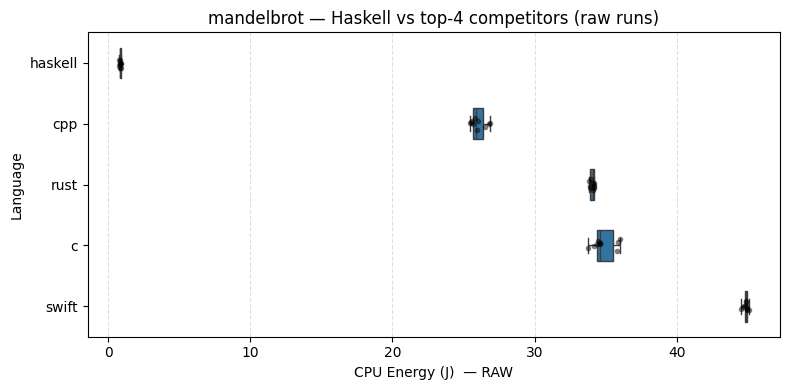

In [4]:
# Pick Haskell + next 4 competitors by mean energy
top5 = order[:5]
subset = mb[mb['language'].isin(top5)]

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=subset, x='cpu_energy_J', y='language', order=top5,
            palette=['#2ca02c'] + ['#1f77b4'] * 4,
            width=0.5, flierprops=dict(marker='x', markersize=6), ax=ax)
sns.stripplot(data=subset, x='cpu_energy_J', y='language', order=top5,
              jitter=True, alpha=0.5, size=4, color='black', ax=ax)

ax.set_xlabel('CPU Energy (J)  — RAW')
ax.set_ylabel('Language')
ax.set_title('mandelbrot — Haskell vs top-4 competitors (raw runs)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## How many × faster/cheaper is Haskell than each language?

In [5]:
haskell_mean = means['haskell']

ratio = (means / haskell_mean).rename('energy_ratio').to_frame()
ratio['mean_J'] = means.round(3)
ratio['energy_ratio'] = ratio['energy_ratio'].round(1)
ratio = ratio.sort_values('energy_ratio')
ratio

,energy_ratio,mean_J
language,,
haskell,1.0,0.846
cpp,30.7,26.020
rust,40.2,34.055
c,41.2,34.833
swift,53.0,44.847
csharp,88.5,74.895
go,115.2,97.497
nodejs,120.1,101.665
fsharp,127.3,107.707


## Full ranked bar — log scale

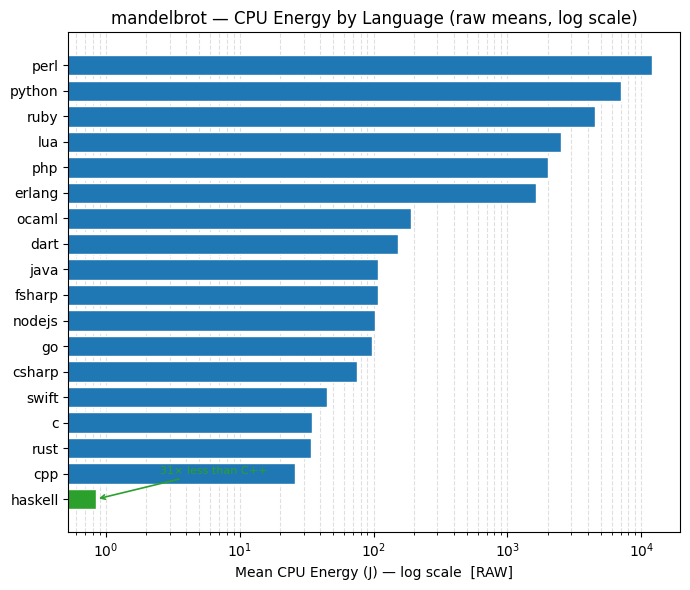

In [6]:
sorted_means = means.sort_values()
colors = ['#2ca02c'] + ['#1f77b4'] * (len(sorted_means) - 1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(sorted_means.index, sorted_means.values, color=colors, edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Mean CPU Energy (J) — log scale  [RAW]')
ax.set_title('mandelbrot — CPU Energy by Language (raw means, log scale)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4, which='both')
ax.set_axisbelow(True)

# Annotate Haskell
hpos = sorted_means.index.tolist().index('haskell')
ax.annotate(f'{sorted_means["cpp"]/sorted_means["haskell"]:.0f}× less than C++',
    xy=(sorted_means['haskell'], hpos),
    xytext=(sorted_means['haskell'] * 3, hpos + 1),
    fontsize=8, color='#2ca02c',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2),
)

plt.tight_layout()
plt.show()